# Copernicus Sea Surface Height (SSH) L3 Near-Real-Time Observation Converter

This notebook inspects the `obs_seq` file created by the DART CMEMS SSH converter.  
The converter itself should be run from the terminal. This notebook focuses on reading, summarizing, and visualizing the output observations.

## Objectives

In this notebook you will learn how to:

- Read two DART `obs_seq` files using pyDARTdiags
- Inspect observation types and metadata
- Visualize observations on a map
- Learn how observation errors change based on ocean bathymetry
- Understand the observation errors in coastal areas and how they are parametrized
- Compute basic observation statistics

## 1. Import Python libraries

In [ ]:
import pydartdiags.obs_sequence.obs_sequence as obsq

import os
import cmocean
import numpy             as np
import pandas            as pd
import xarray            as xr
import cartopy.crs       as ccrs
import cartopy.feature   as cfeature
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates

from pathlib              import Path
from IPython.display      import Markdown, display
from pydartdiags.stats    import stats
from pydartdiags.matplots import matplots as mp

## 2. Define paths

In [ ]:
# Path to DART repo (directory) 
basedir  = Path(f"/glade/derecho/scratch/{os.environ['USER']}/inacawo/DART_training")
roms_dir = Path(f"/glade/derecho/scratch/gharamti/inacawo/roms_rst/roms_ens80")

# Path to the SST converter
ssh_dir = basedir / 'observations' / 'obs_converters' / 'cmems_ssh_l3' 

# Path to the obs_seq file
obs_seq_file_all = ssh_dir / 'work' / 'obs_seq.ssh'
obs_seq_file_trm = ssh_dir / 'work' / 'obs_seq.ssh_trim' 

print(f"obs_seq file: {obs_seq_file_all}")
print(f"obs_seq file: {obs_seq_file_trm}")

# Make sure the obs_Seq file exists
assert obs_seq_file_all.exists(), 'obs_seq file not found'
assert obs_seq_file_trm.exists(), 'obs_seq file not found'

# Roms restart template 
roms_rst = roms_dir / 'roms_mean.nc'

## 3. Read and summarize the obs_seq file

In [ ]:
def summarize_obs_sequence(obs, label):
    """Print and display a compact summary of a DART obs_seq file."""

    df = obs.df.copy()
    df["error_sd"] = np.sqrt(df["obs_err_var"])

    display(Markdown(f"### {label}"))

    print(f"Number of observations : {len(df)}")
    print(f"Number of obs types    : {len(obs.types)}")
    print(f"Time range             : {df['time'].min()} to {df['time'].max()}")
    print(f"Longitude range        : {df['longitude'].min():.2f}° to {df['longitude'].max():.2f}°")
    print(f"Latitude range         : {df['latitude'].min():.2f}° to {df['latitude'].max():.2f}°")

    print("\nObservation types:")
    for kind, name in obs.types.items():
        print(f"  {kind:3d} : {name}\n")

    stats_table = pd.DataFrame({
        "Count": [len(df)],
        "Min SSH (m)": [df["observation"].min()],
        "Max SSH (m)": [df["observation"].max()],
        "Mean SSH (m)": [df["observation"].mean()],
        "Std SSH (m)": [df["observation"].std()],
        "Min Error SD (m)": [df["error_sd"].min()],
        "Max Error SD (m)": [df["error_sd"].max()],
        "Mean Error SD (m)": [df["error_sd"].mean()],
    })
    
    display(stats_table.round(4).style.hide(axis="index"))

    return df

obs_all = obsq.ObsSequence(obs_seq_file_all)
obs_trm = obsq.ObsSequence(obs_seq_file_trm)

df_all = summarize_obs_sequence(obs_all, "Original obs_seq: all SSH observations")
df_trm = summarize_obs_sequence(obs_trm, "Post-processed obs_seq: trimmed SSH observations")

display(Markdown(f"### Comaprison"))

comparison = pd.DataFrame({
    "File": ["Original", "Post-processed"],
    "Observations": [len(df_all), len(df_trm)],
    "Mean Error SD (m)": [
        df_all["error_sd"].mean(),
        df_trm["error_sd"].mean(),
    ],
    "Min Error SD (m)": [
        df_all["error_sd"].min(),
        df_trm["error_sd"].min(),
    ],
    "Max Error SD (m)": [
        df_all["error_sd"].max(),
        df_trm["error_sd"].max(),
    ],
})

n_removed = len(df_all) - len(df_trm)
pct_removed = 100 * n_removed / len(df_all)

display(comparison.round(4).style.hide(axis="index"))

print(f"Removed observations : {n_removed}")
print(f"Removed percentage   : {pct_removed:.1f}%")

## 4. Visualize the Original and Post-Processed SSH observations and errors

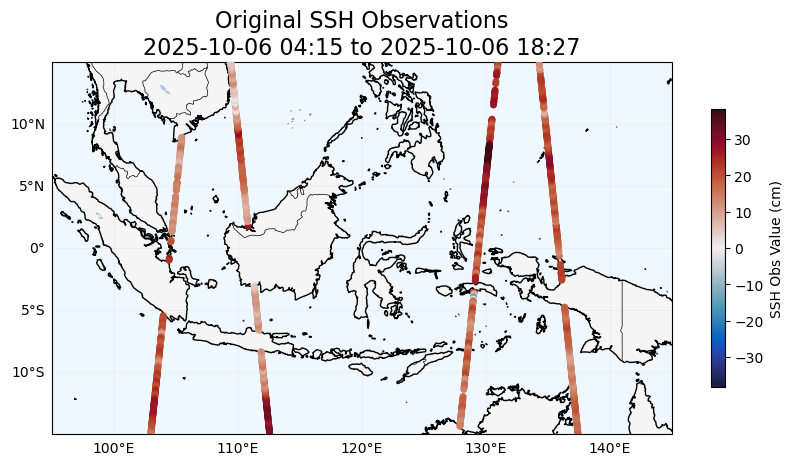


### Interpretation of Original SSH Observations

The figure above shows all along-track satellite sea surface height observations contained in the original observation sequence file. 
Each point represents an individual SSH measurement along a satellite ground track. The colors indicate the observed SSH anomaly, 
while all observations are assigned the same observation error prior to post-processing.


In [163]:
# Extract data from the obs_seq file
df   = obs_all.df.copy()

data = df['observation'] 
lon  = df['longitude']
lat  = df['latitude']
err  = np.sqrt(df['obs_err_var'])
tmin = df["time"].min()
tmax = df["time"].max()

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 6))
ax  = plt.axes(projection=proj)

ax.set_facecolor('aliceblue') 
ax.add_feature(cfeature.LAND, facecolor='whitesmoke', zorder=1) 
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m'), 
               edgecolor='black', facecolor='none', zorder=2)
ax.add_feature(cfeature.LAKES, facecolor='lightsteelblue', zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)

# Observations
vlim = np.nanpercentile(np.abs(data*100), 99)

sc = ax.scatter(lon, lat,
                c=data*100, s = 20,
                cmap=cmocean.cm.balance, linewidth=0.5,
                vmin=-vlim, vmax=vlim,
                zorder=3,
                transform=proj)

cb = plt.colorbar(sc, ax=ax, label='SSH Obs Value (cm)', shrink=0.6)

ax.set_extent([95, 145, -15, 15], crs=proj)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.1)
gl.top_labels   = False
gl.right_labels = False

plt.title(
    f"Original SSH Observations\n"
    f"{tmin:%Y-%m-%d %H:%M} to {tmax:%Y-%m-%d %H:%M}",
    fontsize=16
)
plt.show()

display(Markdown("""
### Interpretation of Original SSH Observations

The figure above shows all along-track satellite sea surface height observations contained in the original observation sequence file. 
Each point represents an individual SSH measurement along a satellite ground track. The colors indicate the observed SSH anomaly, 
while all observations are assigned the same observation error prior to post-processing.
"""))


### Why preprocess SSH observations?

Satellite altimetry measurements can be less reliable in shallow coastal regions because of land contamination, tidal effects, and unresolved coastal processes. The preprocessing workflow therefore:

1. Removes observations located over shallow water.
2. Adjusts observation errors using a bathymetry-dependent error model.
3. Produces a refined observation sequence for assimilation in DART.

The figure below illustrates the resulting observations and assigned uncertainties.


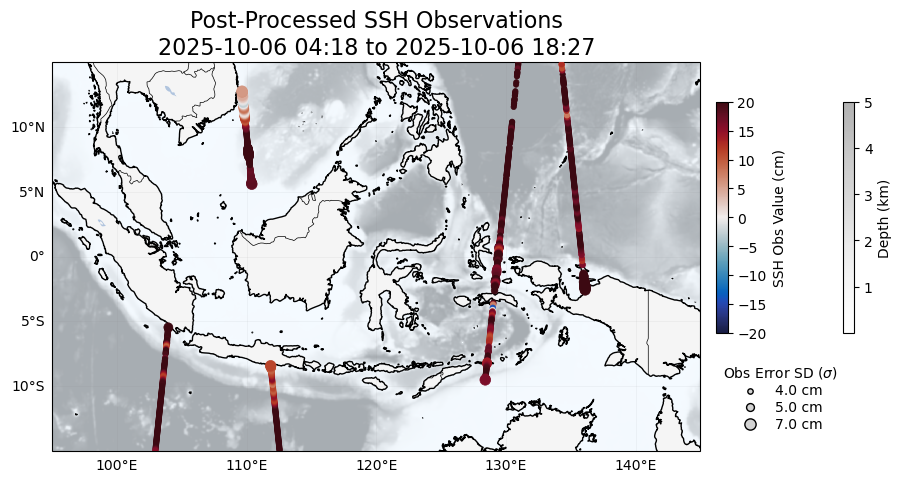


### Interpretation of Post-Processed SSH Observations

The figure above shows the satellite sea surface height observations after applying the SSH preprocessing workflow. Observations located over shallow water 
have been removed using the ROMS bathymetry field. The remaining observations are primarily located in deeper offshore regions where satellite 
altimetry measurements are generally more reliable. Marker color indicates the observed SSH anomaly, while marker size represents the 
assigned observation error standard deviation. Observation errors increase in shallower regions and decrease in deeper water 
according to the bathymetry-dependent error model implemented in the preprocessing script.
The resulting observation sequence is the version used for data assimilation in DART.


In [165]:
display(Markdown("""
### Why preprocess SSH observations?

Satellite altimetry measurements can be less reliable in shallow coastal regions because of land contamination, tidal effects, and unresolved coastal processes. The preprocessing workflow therefore:

1. Removes observations located over shallow water.
2. Adjusts observation errors using a bathymetry-dependent error model.
3. Produces a refined observation sequence for assimilation in DART.

The figure below illustrates the resulting observations and assigned uncertainties.
"""))

# Now, plot the post-processed SSH data 
df   = obs_trm.df.copy()

data = df['observation'] 
lon  = df['longitude']
lat  = df['latitude']
err  = np.sqrt(df['obs_err_var'])
tmin = df["time"].min()
tmax = df["time"].max()

# Need to get the bathymetry from ROMS
with xr.open_dataset(roms_rst) as roms:
    bathy = roms['h'].squeeze()
    lon_g = roms['lon_rho'].squeeze()
    lat_g = roms['lat_rho'].squeeze()

# Generate the map
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 6))
ax  = plt.axes(projection=proj)

# 1. Background 
ax.set_facecolor('aliceblue') 
ax.add_feature(cfeature.LAND, facecolor='whitesmoke', zorder=1) 
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m'), 
               edgecolor='black', facecolor='none', zorder=2)
ax.add_feature(cfeature.LAKES, facecolor='lightsteelblue', zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)

# 2. Bathymetry (zorder 0 so it stays under land/coast)
pcm = ax.pcolormesh(lon_g, lat_g, bathy/1000.0,
                    cmap='Greys', alpha=0.3, 
                    transform=proj,
                    zorder=0)
plt.colorbar(pcm, ax=ax, label='Depth (km)', shrink=0.5, 
             pad=0.01, anchor=(0.0, 0.67))

# 3. Observations (zorder 3 to be on very top)
err_min = np.nanmin(err)
err_max = np.nanmax(err)

def error_to_size(e):
    return 15 + 45 * (e - err_min) / (err_max - err_min)

sizes = error_to_size(err)

sc = ax.scatter(lon, lat,
                c=data*100, s=sizes,
                vmin=-20, vmax=20,
                cmap=cmocean.cm.balance, linewidth=0.5,
                zorder=3,
                transform=proj)

cb = plt.colorbar(sc, ax=ax, label='SSH Obs Value (cm)', 
                shrink=0.5, pad=0.02, anchor=(0.0, 0.67))

ax.set_extent([95, 145, -15, 15], crs=proj)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.1)
gl.top_labels   = False
gl.right_labels = False

# 4. Errors 
legend_errors = [.04, .05, .07]

# Observation marker size represents error standard deviation
for e in legend_errors:
    ax.scatter(
        [], [],
        c='lightgray',
        s=error_to_size(e),
        edgecolor='black',
        label=f'{e*100:.1f} cm'
    )
    
ax.legend(
    title="Obs Error SD ($\sigma$)",
    loc='lower right', 
    bbox_to_anchor=(1.23, 0.02),  
    frameon=False,
    scatterpoints=1,
    labelspacing=0.2 
)

plt.title(
    f"Post-Processed SSH Observations\n"
    f"{tmin:%Y-%m-%d %H:%M} to {tmax:%Y-%m-%d %H:%M}",
    fontsize=16
)
plt.show()

display(Markdown("""
### Interpretation of Post-Processed SSH Observations

The figure above shows the satellite sea surface height observations after applying the SSH preprocessing workflow. Observations located over shallow water 
have been removed using the ROMS bathymetry field. The remaining observations are primarily located in deeper offshore regions where satellite 
altimetry measurements are generally more reliable. Marker color indicates the observed SSH anomaly, while marker size represents the 
assigned observation error standard deviation. Observation errors increase in shallower regions and decrease in deeper water 
according to the bathymetry-dependent error model implemented in the preprocessing script.
The resulting observation sequence is the version used for data assimilation in DART.
"""))

In [ ]:
# Histograms of the original and post-processed SSH data
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(obs_all.df["observation"]*100,
           bins=30, alpha=0.7, label="Original", density=True)

ax[0].hist(obs_trm.df["observation"]*100,
           bins=30, alpha=0.7, label="Post-processed", density=True)

ax[0].set_xlabel("SSH (cm)")
ax[0].set_ylabel("Distribution")
ax[0].legend()
ax[0].grid(True, alpha=0.25)

ax[1].hist(np.sqrt(obs_all.df["obs_err_var"])*100,
           bins=30, alpha=0.7, label="Original")

ax[1].hist(np.sqrt(obs_trm.df["obs_err_var"])*100,
           bins=30, alpha=0.7, label="Post-processed")

ax[1].set_xlabel("Observation Error SD (cm)")
ax[1].set_ylabel("Count")
ax[1].legend()
ax[1].grid(True, alpha=0.25)

plt.show()

display(Markdown("""
### Comparison of Original and Post-Processed Observations

The left panel compares the distribution of SSH observations before and after preprocessing. 
The overall SSH distribution remains similar, indicating that the preprocessing primarily removes observations based on geographic and bathymetric criteria 
rather than altering the observed SSH values. The right panel compares the assigned observation error standard deviations. 
In the original observation sequence, all observations are assigned a uniform 4 cm error. After preprocessing, 
the observation errors are adjusted using a bathymetry-dependent error model, resulting in larger uncertainties 
in shallower regions and smaller uncertainties in deeper water. These adjusted uncertainties are subsequently 
used by DART to determine the relative influence of each observation during assimilation.
"""))

## Key Takeaways
- The original SSH observations are assigned a uniform observation error.
- The preprocessing workflow removes observations located in shallow coastal regions.
- Observation errors are subsequently adjusted using a bathymetry-dependent error model.
- The post-processed observation sequence is recommended for assimilation because it better reflects the varying reliability of satellite altimetry measurements across the domain.